
Dataset cargado: 5729 filas, 12 columnas

Columnas: ['subject_id', 'trial_num', 'nrs_score', 'theta_frontal', 'theta_central', 'theta_parietal', 'alpha_frontal', 'alpha_central', 'alpha_parietal', 'beta_frontal', 'beta_central', 'beta_parietal']
Niveles NRS disponibles: [np.int64(32), np.int64(33), np.int64(34), np.int64(35)]

  subject_id  trial_num  nrs_score  theta_frontal  theta_central  \
0    sub-001          1         33   7.369909e-13   1.007540e-12   
1    sub-001          2         34   9.778087e-13   1.114274e-12   
2    sub-001          3         34   1.780755e-12   2.189734e-12   
3    sub-001          4         35   1.769780e-12   2.784121e-12   
4    sub-001          5         34   1.617100e-12   2.167452e-12   

   theta_parietal  alpha_frontal  alpha_central  alpha_parietal  beta_frontal  \
0    1.976498e-12   3.471938e-13   9.253832e-13    1.710378e-12  2.044873e-13   
1    3.289422e-12   4.195572e-13   1.147543e-12    2.875312e-12  3.576079e-13   
2    3.366693e-12 

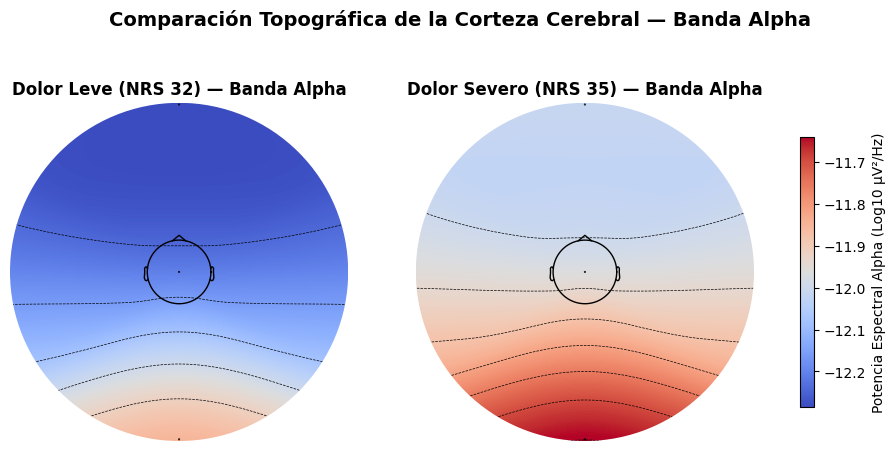


Imagen guardada como 'topomapas_alpha.png'


In [23]:
# ============================================================
# ACTIVIDAD 3 - MAPAS TOPOGRÁFICOS 2D DE LA CORTEZA (EEG)
# ============================================================

# ------------------------------------------------------------
# 1.Instalar la librería de neurotecnología MNE
# ------------------------------------------------------------

!pip install mne -q

# ------------------------------------------------------------
# 2.Importar librerias
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mne

# ------------------------------------------------------------
# 3.Cargar el dataset subido directamente a Colab
# (arrastrarlo al panel de archivos del lado izquierdo antes de ejecutar)
# ------------------------------------------------------------
df_eeg = pd.read_csv('dataset_features_eeg.csv')

# Verificar que cargó bien
print(f"\nDataset cargado: {df_eeg.shape[0]} filas, {df_eeg.shape[1]} columnas")
print(f"\nColumnas: {df_eeg.columns.tolist()}")
print(f"Niveles NRS disponibles: {sorted(df_eeg['nrs_score'].unique())}\n")
print(df_eeg.head())

# ------------------------------------------------------------
# 4.Aplicar transformación Log10 a la banda Alpha
# Los valores de potencia espectral son muy pequeños (ej: 1e-13)
# Log10 los convierte en números manejables para visualizar
# ------------------------------------------------------------
df_alpha = df_eeg.copy()

for col in ['alpha_frontal', 'alpha_central', 'alpha_parietal']:
    df_alpha[col] = np.log10(df_eeg[col])

print("\nValores Alpha transformados (Log10):\n")
print(df_alpha[['alpha_frontal', 'alpha_central', 'alpha_parietal']].describe())

# Tradicionalmente la escla de dolor es del 0 al 10, pero en este dataset se uso
# desde el 0 al 100 por lo que en este dataset se usa NRS 32 (dolor leve) y NRS 35 (dolor severo)
nrs_min = df_eeg['nrs_score'].min()  # 32
nrs_max = df_eeg['nrs_score'].max()  # 35

# ------------------------------------------------------------
# 5.Calcular promedios de potencia Alpha para cada nivel
# ------------------------------------------------------------
nrs_leve = df_alpha[df_alpha['nrs_score'] == nrs_min][
    ['alpha_frontal', 'alpha_central', 'alpha_parietal']
].mean().values

nrs_severo = df_alpha[df_alpha['nrs_score'] == nrs_max][
    ['alpha_frontal', 'alpha_central', 'alpha_parietal']
].mean().values

print(f"\nPromedios Alpha Log10 — NRS {nrs_min} (Dolor Leve):")
print(f"  \n  Frontal:  {nrs_leve[0]:.4f}")
print(f"  Central:  {nrs_leve[1]:.4f}")
print(f"  Parietal: {nrs_leve[2]:.4f}")

print(f"\nPromedios Alpha Log10 — NRS {nrs_max} (Dolor Severo):")
print(f"  \n  Frontal:  {nrs_severo[0]:.4f}")
print(f"  Central:  {nrs_severo[1]:.4f}")
print(f"  Parietal: {nrs_severo[2]:.4f}\n")

# ------------------------------------------------------------
# 6.Coordenadas espaciales de cada electrodo (vista de la cabeza desde arriba)
# Formato: [X (izquierda/derecha), Y (adelante/atrás)]
# ------------------------------------------------------------

print(f"\t\tMAPA TOPOGRÁFICO:\n")
coordenadas = np.array([
    [0.0,  0.5],   # Frontal  (Fz) — parte delantera
    [0.0,  0.0],   # Central  (Cz) — parte media
    [0.0, -0.5]    # Parietal (Pz) — parte trasera
])

# Escala fija y compartida entre ambos mapas para comparación justa
vmin = min(nrs_leve.min(), nrs_severo.min())
vmax = max(nrs_leve.max(), nrs_severo.max())

# Crear figura con dos mapas lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Mapa NRS mínimo — Dolor Leve
im1, _ = mne.viz.plot_topomap(
    nrs_leve,
    coordenadas,
    axes=axes[0],
    show=False,
    cmap='coolwarm',
    sensors=True,
    vlim=(vmin, vmax)
)
axes[0].set_title(f'Dolor Leve (NRS {nrs_min}) — Banda Alpha',
                  fontsize=12, fontweight='bold')

# Mapa NRS máximo — Dolor Severo
im2, _ = mne.viz.plot_topomap(
    nrs_severo,
    coordenadas,
    axes=axes[1],
    show=False,
    cmap='coolwarm',
    sensors=True,
    vlim=(vmin, vmax)
)
axes[1].set_title(f'Dolor Severo (NRS {nrs_max}) — Banda Alpha',
                  fontsize=12, fontweight='bold')

# Barra de color compartida
plt.colorbar(
    im1,
    ax=axes.ravel().tolist(),
    orientation='vertical',
    shrink=0.7,
    label='Potencia Espectral Alpha (Log10 µV²/Hz)'
)

plt.suptitle(
    'Comparación Topográfica de la Corteza Cerebral — Banda Alpha',
    fontsize=14, fontweight='bold', y=1.02
)

# Guardar imagen directamente en Colab (la descargas luego con clic derecho)
plt.savefig('topomapas_alpha.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nImagen guardada como 'topomapas_alpha.png'")


# Nueva sección